# S6 — Ejercicio: Pipeline completo de OCR con EasyOCR

**Caso de estudio**: se te proporciona la fotografia de una pagina de libro.
Tu tarea es extraer y organizar todo el texto que contiene usando EasyOCR.

Implementaras el pipeline completo paso a paso:

| Paso | Tarea |
|------|-------|
| 1 | Cargar y explorar la imagen |
| 2 | Ejecutar EasyOCR y explorar los resultados brutos |
| 3 | Visualizar las detecciones sobre la imagen |
| 4 | Analizar el nivel de confianza |
| 5 | Filtrar detecciones por confianza |
| 6 | Reconstruir el texto en orden de lectura |
| 7 | Preguntas de reflexion |

> Todas las herramientas necesarias estan en el notebook de clase `S6_CV_OCR.ipynb`.

## Configuracion

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon

from skimage import io
from skimage.color import rgb2gray

import warnings
warnings.filterwarnings('ignore')

Ejecuta la celda siguiente **una sola vez** en local (o siempre en Google Colab)
para instalar los paquetes y cargar los modelos. Puedes continuar leyendo mientras termina.

In [ ]:
# Instalacion de paquetes (solo primera vez en local)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import subprocess, sys
if IN_COLAB:
    subprocess.run(['apt-get', '-qq', 'install', 'tesseract-ocr', 'tesseract-ocr-spa'], check=True)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'easyocr'])

# Carga de modelos (cada vez que abras el notebook)
import easyocr
reader = easyocr.Reader(['es', 'en'], gpu=False, verbose=True)
print('Modelos cargados. Todo listo.')

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteModelos cargados. Todo listo.


## Paso 1 — Cargar y explorar la imagen

Carga la imagen `img/principito.png`.

> **Recuerda**: las imagenes PNG pueden tener canal alfa (RGBA, 4 canales).
> Las funciones de OCR esperan RGB (3 canales). Si la imagen tiene 4 canales,
> descarta el cuarto con `img[:, :, :3]`.

Tras cargar la imagen:
- Imprime sus dimensiones (`shape`) y tipo de dato (`dtype`)
- Muestra la imagen con `plt.imshow`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# PASO 1: Carga la imagen
# ── ESCRIBE AQUI TU CODIGO ──────────────────────────────────────────────────
img = io.imread('/content/beer.png')

print(f'Dimensiones: {img.shape}   dtype: {img.dtype}')

Dimensiones: (360, 360, 3)   dtype: uint8


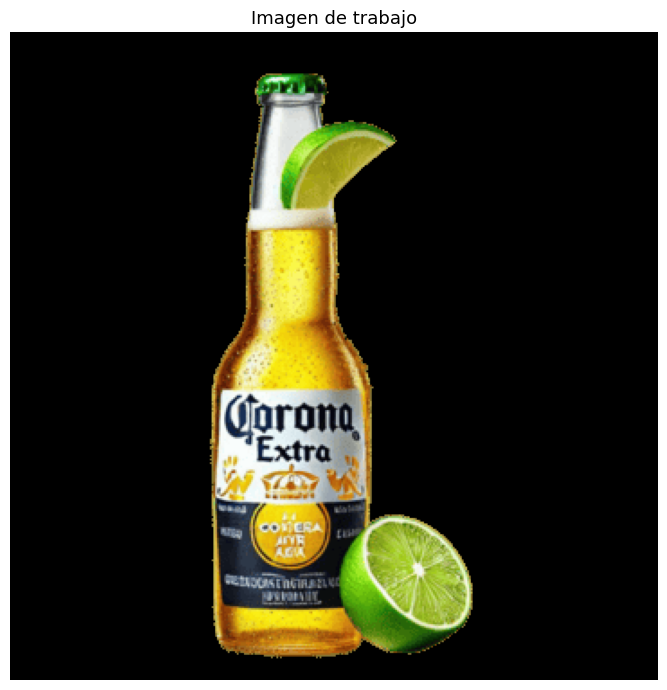

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(img)
ax.set_title('Imagen de trabajo', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Paso 2 — Ejecutar EasyOCR

Ejecuta `reader.readtext()` sobre la imagen con `detail=1`.

Recuerda el formato de salida de cada deteccion:

| Elemento | Tipo | Descripcion |
|----------|------|-------------|
| `bbox` | `[[x1,y1],[x2,y2],[x3,y3],[x4,y4]]` | 4 esquinas del bounding box |
| `texto` | `str` | Texto reconocido |
| `confianza` | `float [0,1]` | Probabilidad estimada |

Imprime:
- El numero total de detecciones
- Las primeras 5 detecciones (bbox, texto, confianza)

In [ ]:
reader = easyocr.Reader(['es', 'en'], gpu=True, verbose=True)

In [ ]:
# PASO 2: Ejecuta EasyOCR
# ── ESCRIBE AQUI TU CODIGO ──────────────────────────────────────────────────

results = reader.readtext(img, detail=1)

print(f'Total de detecciones: {len(results)}')
print()
print('-- Primeras 5 detecciones -----')
# Recorre results[:5] e imprime cada (bbox, texto, confianza)
# ── ESCRIBE AQUI TU CODIGO ──────────────────────────────────────────────────

for bbox, texto, conf in results[:5]:
    print(f'  [{conf:.3f}]  {texto!r:30}  bbox: {bbox[0]}…{bbox[2]}')

Total de detecciones: 3

-- Primeras 5 detecciones -----
  [0.406]  '[Qorono'                       bbox: [np.int32(116), np.int32(198)]…[np.int32(196), np.int32(226)]
  [0.986]  "'Éxtra"                        bbox: [np.int32(132), np.int32(218)]…[np.int32(182), np.int32(242)]
  [0.102]  'Cuingir'                       bbox: [np.int32(122), np.int32(299)]…[np.int32(165), np.int32(311)]


In [ ]:
for i in results[:5]:
  print(i)

([[np.int32(116), np.int32(198)], [np.int32(196), np.int32(198)], [np.int32(196), np.int32(226)], [np.int32(116), np.int32(226)]], '[Qorono', np.float64(0.40572353795010707))
([[np.int32(132), np.int32(218)], [np.int32(182), np.int32(218)], [np.int32(182), np.int32(242)], [np.int32(132), np.int32(242)]], "'Éxtra", np.float64(0.9862052950508368))
([[np.int32(122), np.int32(299)], [np.int32(165), np.int32(299)], [np.int32(165), np.int32(311)], [np.int32(122), np.int32(311)]], 'Cuingir', np.float64(0.10165915503752164))


## Paso 3 — Visualizar las detecciones

Implementa la funcion `mostrar_detecciones(img, results, umbral)` que:

1. Crea una figura con `plt.subplots`
2. Muestra la imagen con `ax.imshow`
3. Para cada deteccion con confianza >= `umbral`:
   - Dibuja el **cuadrilatero** del bbox usando `matplotlib.patches.Polygon`
     (los 4 vertices del bbox forman un poligono cerrado)
   - Anota el texto y la confianza junto al primer vertice
4. Llama a `plt.show()`

> **Pista**: el bbox de EasyOCR es una lista de 4 pares `[x, y]`.
> Para convertirlo a array NumPy: `pts = np.array(bbox, dtype=np.int32)`
> Para crear el poligono: `Polygon(pts, closed=True, fill=False, edgecolor='crimson', linewidth=2)`

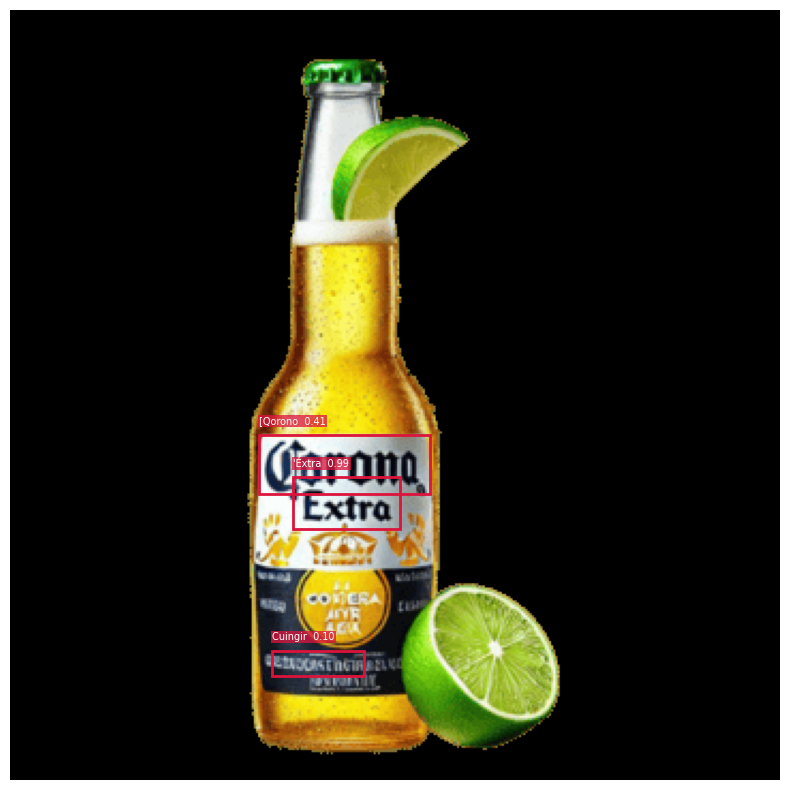

In [ ]:
# PASO 3: Implementa la funcion de visualizacion
def mostrar_detecciones(img, results, umbral=0.0):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)

    for (bbox, texto, confianza) in results:
        if confianza >= umbral:
            pts = np.array(bbox, dtype=np.int32)
            poly = Polygon(pts, closed=True, fill=False, edgecolor='crimson', linewidth=2)
            ax.add_patch(poly)
            ax.text(pts[0, 0], pts[0, 1] - 5, f'{texto}  {confianza:.2f}',
                    color='white', fontsize=7,
                    bbox=dict(facecolor='crimson', alpha=0.75, pad=1, edgecolor='none'))

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

# Prueba con todas las detecciones (umbral=0.0)
mostrar_detecciones(img, results, umbral=0.0)

## Paso 4 — Analizar el nivel de confianza

Crea un `pd.DataFrame` con las columnas `Texto detectado` y `Confianza`,
ordenado de mayor a menor confianza.

Luego imprime:
- Total de detecciones
- Confianza media y mediana

Finalmente, dibuja un **histograma** de la distribucion de confianzas.

In [ ]:
# PASO 4a: DataFrame de resultados
# ── ESCRIBE AQUI TU CODIGO ──────────────────────────────────────────────────
df = pd.DataFrame(
        [(texto, round(conf, 4)) for (_, texto, conf) in results],
        columns=['Texto detectado', 'Confianza']
    ).sort_values('Confianza', ascending=False).reset_index(drop=True)

print(f'Total detecciones: {len(df)}')
print(f'Confianza media:   {df['Confianza'].mean()}')
print(f'Confianza mediana: {df['Confianza'].median()}')
print()
display(df.head(20))

Total detecciones: 3
Confianza media:   0.4978666666666666
Confianza mediana: 0.4057



,Texto detectado,Confianza
0,'Éxtra,0.9862
1,[Qorono,0.4057
2,Cuingir,0.1017


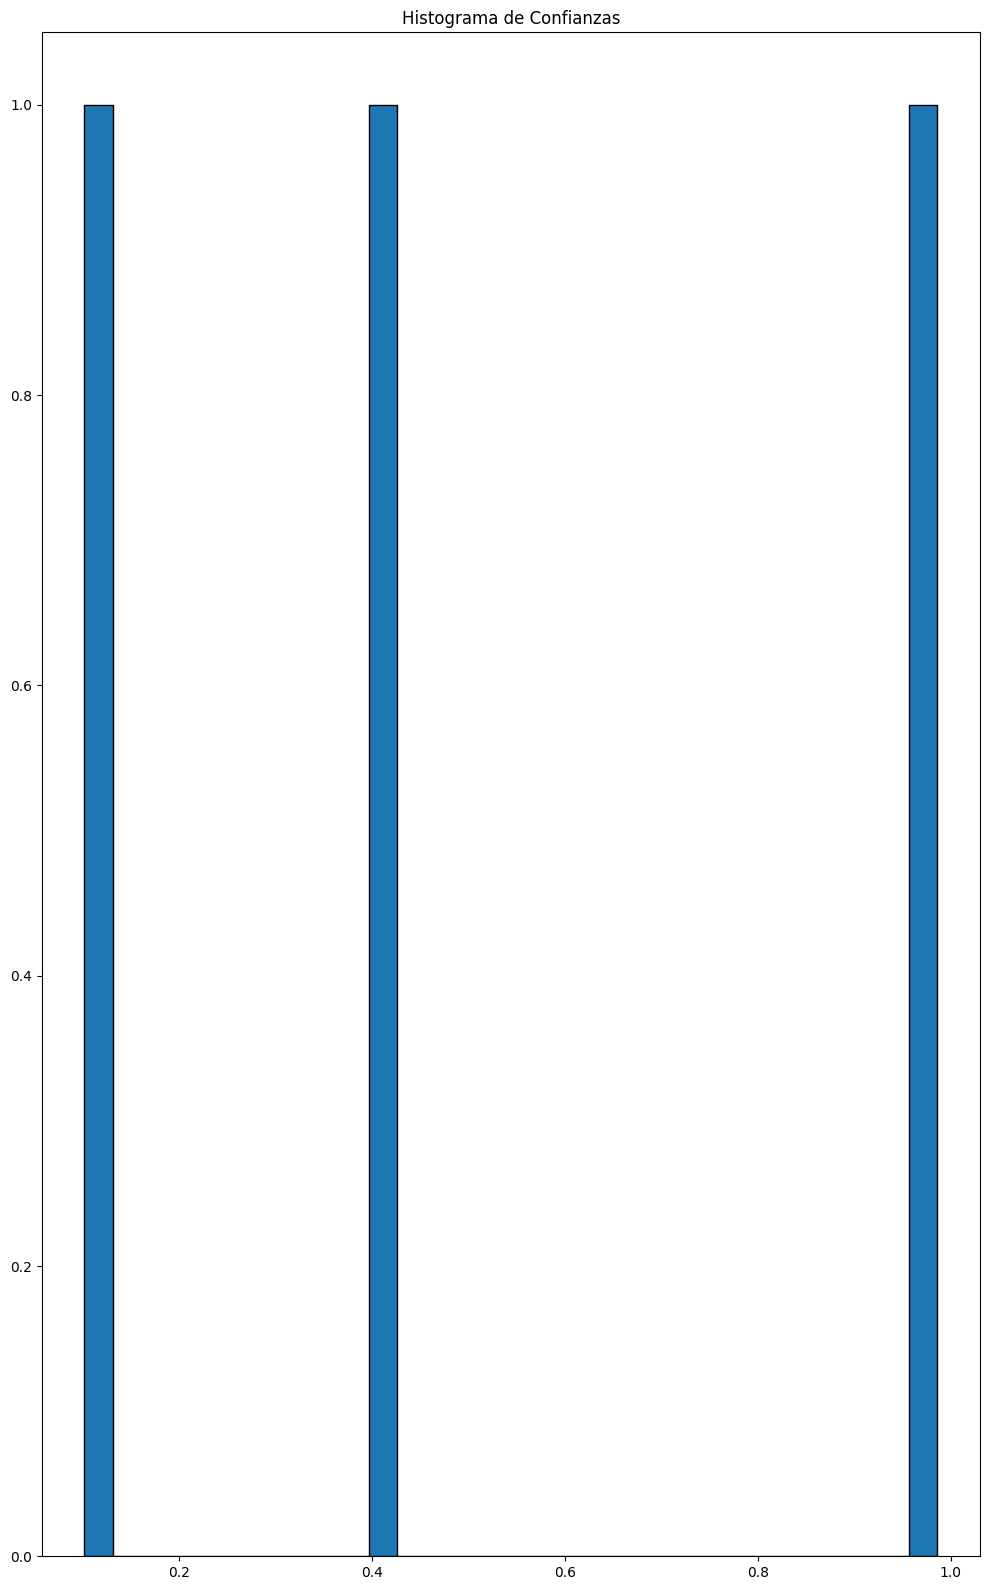

In [ ]:
# PASO 4b: Histograma de confianzas

fig, axes = plt.subplots(1, figsize=(10,16))

axes.hist(df['Confianza'], bins=30, edgecolor='k')
axes.set_title('Histograma de Confianzas')

plt.tight_layout()
plt.show()

## Paso 5 — Filtrar por confianza

Prueba tres valores de umbral: **0.2**, **0.5** y **0.8**.

Para cada uno:
- Cuenta cuantas detecciones quedan
- Visualiza el resultado con `mostrar_detecciones`

Luego responde: *?que umbral elegirías para esta imagen y por que?*

Detecciones con un umbral de 0.2: 2


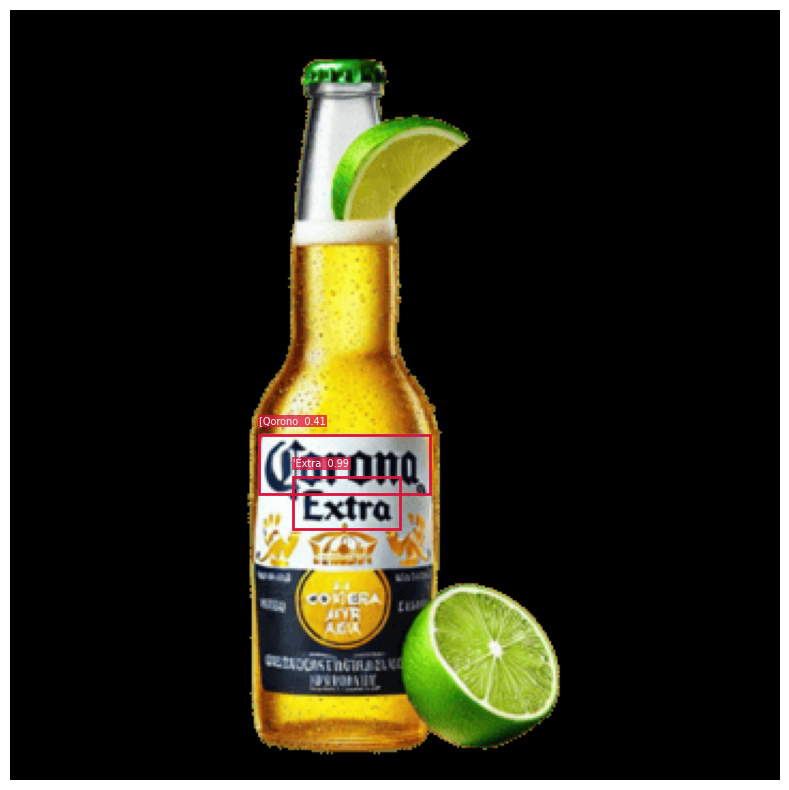

Detecciones con un umbral de 0.5: 1


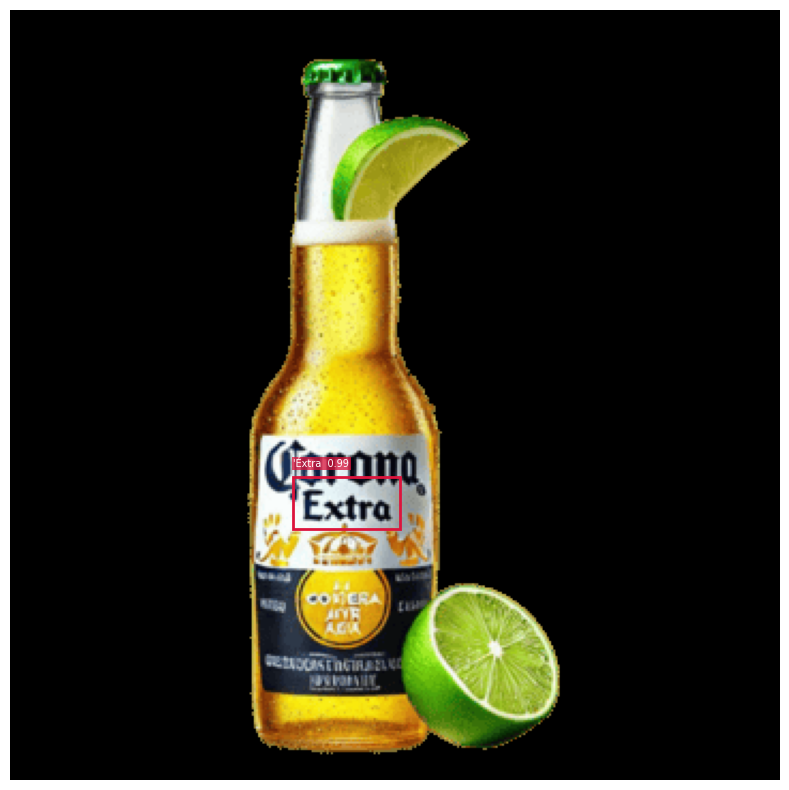

Detecciones con un umbral de 0.8: 1


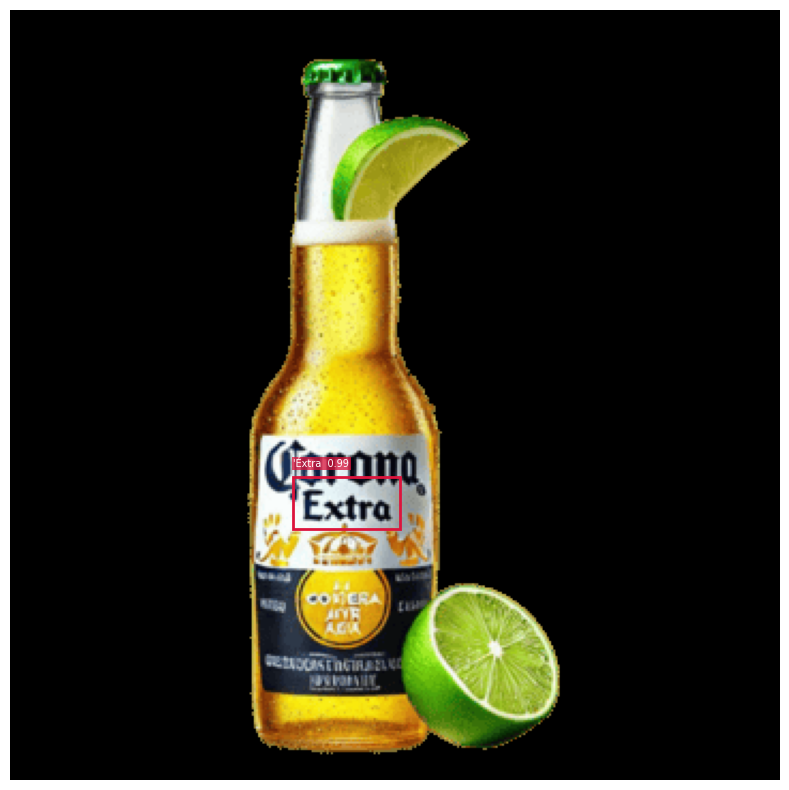

In [ ]:
# PASO 5: Prueba los tres umbrales
for umbral in [0.2, 0.5, 0.8]:
    print(f'Detecciones con un umbral de {umbral}: {len(df[df['Confianza'] > umbral])}')
    mostrar_detecciones(img, results, umbral)
    pass

## Paso 6 — Reconstruir el texto en orden de lectura

EasyOCR devuelve las detecciones en el orden interno de su pipeline.
Para reconstruir el orden de lectura natural hay que **ordenar por posicion**:
primero de arriba a abajo (coordenada Y), luego de izquierda a derecha (coordenada X).

El primer vertice del bbox `bbox[0]` tiene coordenadas `[x, y]`.

Implementa la funcion `texto_ordenado(results, umbral)` que:
1. Filtra las detecciones por confianza >= `umbral`
2. Ordena por `(bbox[0][1], bbox[0][0])` — es decir, (Y, X)
3. Devuelve el texto de las detecciones ordenadas unido con espacios

Compara la salida **sin ordenar** y **ordenada** con `umbral=0.4`.

In [ ]:
# PASO 6: Implementa texto_ordenado
def texto_ordenado(results, umbral=0.4):
    filtrados = [(bbox, t, c) for (bbox, t, c) in results if c >= umbral]
    ordenados = sorted(filtrados, key=lambda r: (r[0][0][1], r[0][0][0]))
    return ' '.join(t for (_, t, _) in ordenados)

umbral_final = 0.4

texto_sin_orden = ' '.join(t for (_, t, c) in results if c >= umbral_final)
texto_con_orden = texto_ordenado(results, umbral=umbral_final)

print('-- Sin orden de lectura ----------------------------------------')
print(texto_sin_orden[:500])
print()
print('-- Con orden de lectura ----------------------------------------')
print(texto_con_orden[:500])

-- Sin orden de lectura ----------------------------------------
[Qorono 'Éxtra

-- Con orden de lectura ----------------------------------------
[Qorono 'Éxtra


## Paso 7 — Preguntas de reflexion

1. **Confianza**: observa las detecciones con confianza mas baja. ?Corresponden
   a errores reales o a texto valido pero dificil? ?Que tienen en comun?

2. **Bounding boxes**: los bounding boxes de EasyOCR son cuadrilateros (4 vertices),
   no rectangulos. ?En que tipo de imagenes es esto una ventaja clara?

3. **Orden de lectura**: compara el texto antes y despues de ordenar.
   ?En que partes del texto se nota mas la diferencia? ?Por que crees que
   EasyOCR no devuelve el texto ya ordenado?

4. **Preprocesado**: esta imagen es un escaneo de alta calidad. ?Aplicarias
   algun preprocesado antes de pasar la imagen a EasyOCR? ?Por que si o por que no?

5. **(Avanzado)**: EasyOCR usa CRAFT para la deteccion. Busca un ejemplo de imagen
   donde CRAFT falle o produzca resultados inesperados y explica el motivo.